# Assignment 1 - Regression Summative: OLS, Spatial Regression, (m)GWR:

In this workbook, Airbnb listingg for Edinburgh are analysed using OLS, Spatial Error, Spatial Lag, Spatial Durbin models, as well as GWR and multiscale GWR. This study will:

- Find the best factors to estimate Airbnb listing price in Edinburgh.
- Perform regression analysis and visualise regression results.
- Evaluate which model has the best performance.


In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import geopandas as gpd
import seaborn as sns
from libpysal.weights import DistanceBand, KNN
from esda.moran import Moran
from spreg import OLS, ML_Error, ML_Lag, GM_Error, GM_Lag
from scipy import stats
from shapely.geometry import Point
from splot.esda import moran_scatterplot, plot_moran
import contextily as ctx
from matplotlib.ticker import FuncFormatter
import pyproj
from libpysal.weights import lag_spatial
from scipy.stats import norm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import libpysal as ps 
from libpysal.weights import Queen
from esda.moran import Moran
import statsmodels.api as sm

# MGWR functions
from mgwr.gwr import GWR,MGWR
from mgwr.sel_bw import Sel_BW

### 1.1 Load and inspect the Airbnb Data:
Begin by loading and inspecting the data using Pandas and the pd.info() and pd.describe() functions to explore data dimnesions, columns, and find null values.

After inspecting the data, the following columns are **kept** for analysis:
- latitude, longitude
- room_type
- accomodates
- bathrooms
- bedrooms
- price
- Number of Reviews
- review_scores_rating
- Host is superhost
- Host Identity verified

In [127]:
# Read the dataset and check the structure of the data:
df = pd.read_csv(r'Edinburgh_ABnB_List_Data\listings.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4936 entries, 0 to 4935
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4936 non-null   int64  
 1   listing_url                                   4936 non-null   str    
 2   scrape_id                                     4936 non-null   int64  
 3   last_scraped                                  4936 non-null   str    
 4   source                                        4936 non-null   str    
 5   name                                          4936 non-null   str    
 6   description                                   4880 non-null   str    
 7   neighborhood_overview                         2776 non-null   str    
 8   picture_url                                   4936 non-null   str    
 9   host_id                                       4936 non-null   int64  
 10 

In [128]:
# Select columns relevant to the regression analysis and check for missing values:
columns_to_keep = ['latitude', 'longitude', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'price',
                   'number_of_reviews', 'review_scores_rating', 'host_identity_verified','host_is_superhost']

df = df[columns_to_keep].copy()

df.head()

for col in columns_to_keep:
    print(f"{col}: {df[col].isnull().sum()} null values")

latitude: 0 null values
longitude: 0 null values
room_type: 0 null values
accommodates: 0 null values
bathrooms: 3 null values
bedrooms: 3 null values
price: 11 null values
number_of_reviews: 0 null values
review_scores_rating: 286 null values
host_identity_verified: 2 null values
host_is_superhost: 144 null values


### 1.2 Data Cleaning:
There are missing values for the selected factors, and some factors are encoded as strings. The variables must be transformed to numeric data types, and missing values are removed from the datatset.

A binary variable is created for the *host_identity_verified* and *host_is_superhost* columns - they are coded to 1 or 0, if they are true or false, respectively.

Similarly, the *room_type* column is separated into three binary columns for each of the room types - Entire home/apt, Private room, and Shared room.

In [197]:
# Clean price column and convert to float:
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)
# Convert binary variables, t or f, (host_identity_verified and host_is_superhost) to numeric (0, 1):
df['host_identity_verified_binary'] = df['host_identity_verified'].map({'t': 1, 'f': 0})
df['host_is_superhost_binary'] = df['host_is_superhost'].map({'t': 1, 'f': 0})

# Separate room_type into dummy variables:
df['entire_home_apt'] = (df['room_type'] == 'Entire home/apt').astype(int)
df['private_room'] = (df['room_type'] == 'Private room').astype(int)
df['shared_room'] = (df['room_type'] == 'Shared room').astype(int)

df = df.drop(columns=['room_type', 'host_identity_verified', 'host_is_superhost'])

KeyError: 'host_identity_verified'

In [ ]:
# Remove NA values and review the updated dataset:
updated_cols = df.columns
df_updated = df.dropna(subset = updated_cols)

df_updated.describe()

,latitude,longitude,accommodates,bathrooms,bedrooms,price,number_of_reviews,review_scores_rating,host_identity_verified_binary,host_is_superhost_binary,entire_home_apt,private_room,shared_room
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,55.950103,-3.199775,3.515778,1.294111,1.634889,297.351556,119.600667,4.779387,0.931333,0.481111,0.718667,0.272667,0.004000
std,0.016415,0.041003,2.020559,0.635942,0.967018,1218.697214,154.923982,0.284343,0.252915,0.499699,0.449700,0.445380,0.063126
min,55.857624,-3.442540,1.000000,0.000000,0.000000,23.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.942589,-3.212316,2.000000,1.000000,1.000000,107.000000,15.000000,4.700000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,55.951085,-3.194188,3.000000,1.000000,1.000000,158.000000,60.000000,4.850000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,55.959305,-3.178239,4.000000,1.500000,2.000000,232.000000,168.000000,4.950000,1.000000,1.000000,1.000000,1.000000,0.000000
max,55.991950,-3.081541,16.000000,12.000000,12.000000,18465.000000,1541.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Looking at the updated data structure, the maximum value for the accomodates, bathrooms, bedrooms, price columns are much higher than the 75th percentile. This could indicate the presence of anomalous values. Draw a box plot for these columns to investigate further: 

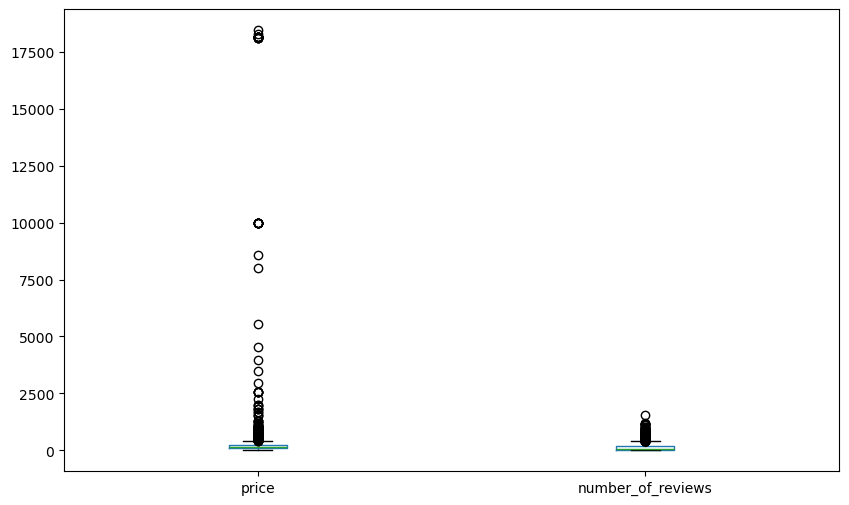

In [ ]:
boxplot = df_updated.boxplot(column=['price', 'number_of_reviews'],
                     grid=False, figsize=(10, 6))
plt.show()

In [ ]:
# Remove outliers from the price column using the 95th percentile:
price_95th_percentile = df_updated['price'].quantile(0.95)
print(f"Number of price records removed: {len(df_updated[df_updated['price'] > price_95th_percentile])}")
df_updated = df_updated[df_updated['price'] <= price_95th_percentile]

Number of price records removed: 224


There are some listings where the number of bedrooms and bathrooms are 0. Remove these such that each listing has at least 1 bedroom and bathroom. 

We have removed 319 records due to data cleaning, which is XX% of data.

In [ ]:
# Remove outliers from accommodates, bathrooms, bedrooms:
df_updated = df_updated[df_updated['bedrooms'] > 0]
print(f"Number of bedrooms records removed: {len(df_updated[df_updated['bedrooms'] == 0])}")
df_updated = df_updated[df_updated['bathrooms'] > 0]
print(f"Number of bathrooms records removed: {len(df_updated[df_updated['bathrooms'] == 0])}")
len(df_updated)

Number of bedrooms records removed: 0
Number of bathrooms records removed: 0


4181

### 1.3 Find the best factors for regression analysis:

The effects of multicollinearity must be minimised. The Variance Inflation Factor (VIF) assesses the correlation between the independent variables. Any factor with a VIF of 10 or greater should be removed:

In [134]:
# Isolate the key independent variables for the regression model:
x_cols = ['accommodates', 'bathrooms', 'bedrooms', 'number_of_reviews',
          'review_scores_rating', 'host_identity_verified_binary', 'host_is_superhost_binary',
            'entire_home_apt', 'private_room', 'shared_room']

# Create a new DataFrame with the independent variables for VIF calculation:
X_vif = df_updated[x_cols] 

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                        Variable         VIF
4           review_scores_rating  144.225951
7                entire_home_apt   99.642091
8                   private_room   39.718360
0                   accommodates   17.718215
2                       bedrooms   17.302786
5  host_identity_verified_binary   14.129916
1                      bathrooms   10.212353
6       host_is_superhost_binary    2.252572
3              number_of_reviews    1.764928
9                    shared_room    1.373845


From the VIF results, *review_scores_rating*, *entire_home_apt*, *private_room*, *accommodates*, *bedrooms*, *host_identity_verified_binary*, and *bathrooms* show high multicollinearity. The following are removed from the data:
- Accomodates: The accomodates is correlated with the number of bedrooms.
- Bathrooms: The number of bathrooms is correlated with the number of bedrooms.
- Host identity verified (binary)
- Review Scores Ratings

Removing these columns leads us to data where all VIF values are less than 10, which is sufficient for regression analysis.

In [135]:
x_cols = ['bedrooms', 'number_of_reviews', 'host_is_superhost_binary',
            'entire_home_apt', 'private_room', 'shared_room']

X_vif = df_updated[x_cols] 

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data.sort_values('VIF', ascending=False))

                   Variable       VIF
3           entire_home_apt  6.207364
0                  bedrooms  5.531110
2  host_is_superhost_binary  2.106502
4              private_room  1.956945
1         number_of_reviews  1.754201
5               shared_room  1.005431


In [198]:
df_updated = df_updated.drop(columns=['accommodates', 'bathrooms', 'review_scores_rating', 'host_identity_verified_binary'])

KeyError: "['accommodates', 'bathrooms', 'review_scores_rating', 'host_identity_verified_binary'] not found in axis"

## 2 Regression Analysis

### 2.1 Spatial Weight Matrix
The spatial weight matrix is used to define the spatial relationships between the data. The K-Nearest Neighbours method is used to connect each point to it's k nearest neighbours. 

Looking at the mapped listings below, the listings are grouped towards the centre of Edinburgh, with very few listings in Outer Edinburgh.

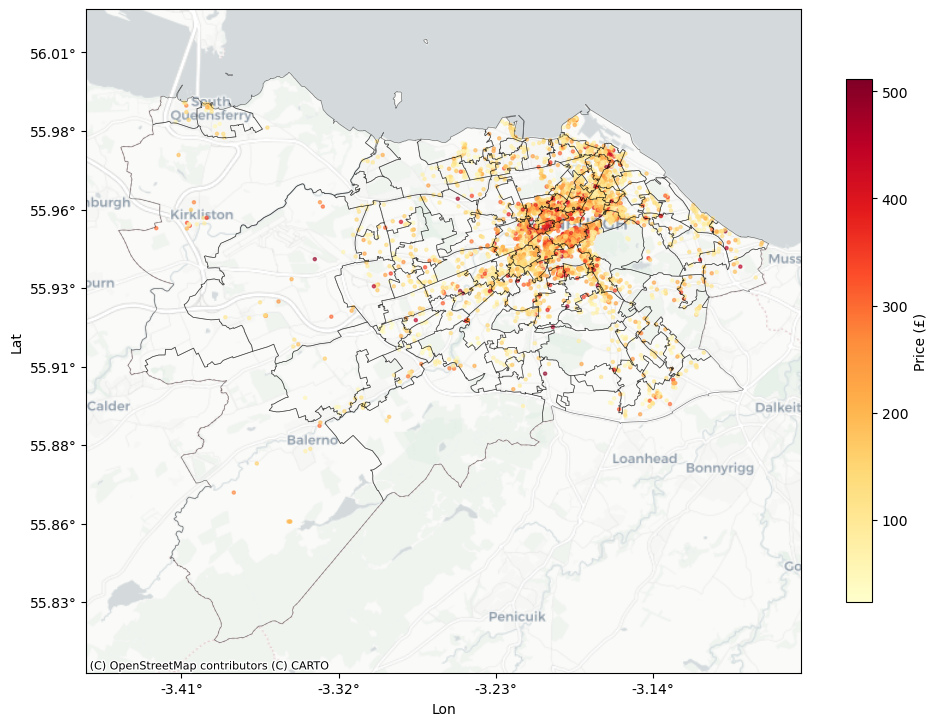

In [137]:
geometry = [Point(xy) for xy in zip(df_updated['longitude'], df_updated['latitude'])]
# initial data are in WGS84
gdf = gpd.GeoDataFrame(df_updated, geometry=geometry, crs='EPSG:4326')

# convert listings to web Mercator for plotting with basemap
gdf = gdf.to_crs(epsg=3857)

# load neighbourhood boundaries and transform as well:
neigh = gpd.read_file(r'Edinburgh_ABnB_List_Data\neighbourhoods.geojson')
neigh_web = neigh.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))

# plot neighbourhood boundaries:
neigh_web.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5, alpha=0.5)

# Plot the listings colours by price using web Mercator geometry
x = gdf.plot(
    ax=ax, column='price', cmap='YlOrRd',
    markersize=5, alpha=0.6, legend=True,
    legend_kwds={'label': 'Price (£)', 'shrink': 0.7}
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_xlabel('Lon')
ax.set_ylabel('Lat')

transformer = pyproj.Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)

def lon_formatter(x, pos):
    lon, _ = transformer.transform(x, 0)
    return f'{lon:.2f}°'

def lat_formatter(y, pos):
    _, lat = transformer.transform(0, y)
    return f'{lat:.2f}°'

ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))

plt.tight_layout()
plt.show()

## K = 12
To ensure there are no islands.

In [138]:
# Convert to appropriate coordinates for distance calculations:
gdf_proj = gdf.to_crs('EPSG:27700')
coords = np.column_stack((gdf_proj.geometry.x, gdf_proj.geometry.y))

# ---- KNN Weight Matrix ----
w_knn = KNN.from_array(coords, k=12)
w_knn.transform = 'R'

print("=== KNN Spatial Weights (k=12) ===")
print(f"Number of observations: {w_knn.n}")
print(f"Mean number of neighbours: {w_knn.mean_neighbors:.1f}")
print(f"Min neighbours: {w_knn.min_neighbors}")
print(f"Max neighbours: {w_knn.max_neighbors}")

=== KNN Spatial Weights (k=12) ===
Number of observations: 4181
Mean number of neighbours: 12.0
Min neighbours: 12
Max neighbours: 12


### 2.2 Ordinary Least Squares (OLS)

In [139]:
# Dependent variable
df_updated['log_price'] = np.log(df_updated['price'])
y_col = 'log_price'
ys = df_updated[[y_col]].values

xs = df_updated[x_cols].values

# Run OLS
ols = OLS(
    ys, xs,
    w=w_knn,
    name_y=y_col,
    name_x=x_cols,
    name_ds='Edinburgh Airbnb Listings',
    spat_diag=True 
)

print(ols.summary)

# Moran's I test for spatial autocorrelation in OLS residuals
residuals = ols.u.flatten()
moran = Moran(residuals, w_knn)

print("====================== Global Moran's I Test on OLS Residuals ======================")
print(f"Moran's I:     {moran.I:.4f}")
print(f"Expected I:    {moran.EI:.4f}")
print(f"Z-score:       {moran.z_sim:.4f}")
print(f"P-value:       {moran.p_sim:.4f}")
print()

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :Edinburgh Airbnb Listings
Weights matrix      :     unknown
Dependent Variable  :   log_price                Number of Observations:        4181
Mean dependent var  :      5.0055                Number of Variables   :           7
S.D. dependent var  :      0.5464                Degrees of Freedom    :        4174
R-squared           :      0.5132
Adjusted R-squared  :      0.5125
Sum squared residual:     607.517                F-statistic           :    733.3819
Sigma-square        :       0.146                Prob(F-statistic)     :           0
S.E. of regression  :       0.382                Log likelihood        :   -1900.162
Sigma-square ML     :       0.145                Akaike info criterion :    3814.324
S.E of regression ML:      0.3812                Schwarz criterion     :    3858.693

-----------------------------------------------

From the OLS results, each of the independent variables are significant to the 99th percentile. However, the Morans I value shows significant and positive autocorrelation, implying the price of Airbnb listings in Edinburgh show clustering effects.
- R<sup>2</sup> = 0.5132
- AICc = 3814.324
- Morans I = 0.2212
    - P-value = 0.0010

### 2.3 Spatial Error, Spatial Lag, and Spatial Durbin Regression Models:

The spatial error model implies that the price of any given listing if dependent on the listings features, but there is spatial dependence in the error terms.

In [140]:
from spreg.ml_error import BaseML_Error

sem = BaseML_Error(ys, xs, w_knn)

print(sem.betas)
print(sem.lam)

C:\Users\sammi\AppData\Roaming\Python\Python314\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


[[ 2.83889842e-01]
 [-3.83894760e-04]
 [ 8.52485107e-02]
 [ 4.55313655e+00]
 [ 4.08687065e+00]
 [ 2.09726606e+00]
 [ 6.93709414e-01]]
0.6937094137669912


The spatial lag model assumes the price of a listing is directly influenced by the price of nearby listings. The Spatial autoregressive coefficient of $\rho = 0.42$ is positive and the p-value is significant, suggesting a positive spatial dependence for Airbnb listing price in Edinburgh.

In [141]:
sar = ML_Error(
    ys, xs,
    w=w_knn,
    name_y=y_col,
    name_x=x_cols,
    name_ds='Edinburgh Airbnb Listings'
)

print(sar.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :Edinburgh Airbnb Listings
Weights matrix      :     unknown
Dependent Variable  :   log_price                Number of Observations:        4181
Mean dependent var  :      5.0055                Number of Variables   :           8
S.D. dependent var  :      0.5464                Degrees of Freedom    :        4173
Pseudo R-squared    :      0.5915
Spatial Pseudo R-squared:  0.5251
Log likelihood      :  -1575.4220
Sigma-square ML     :      0.1220                Akaike info criterion :    3166.844
S.E of regression   :      0.3493                Schwarz criterion     :    3217.550

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
--------------------------------------------------

Looking at the spatial lag model:
- R<sup>2</sup><sub>sar</sub> = 0.5188
- AICc<sub>sar</sub> = 3218.706

Which shows an improvement on the OLS model.

The spatial Durbin model combines the effects of the spatial error and spatial lag models. It assesses the impact of neighbouring prices on a given listing, and the effect of the neighbours features on a listing.

In [142]:
wx_cols = ['W_' + col for col in x_cols]
wx_array = np.column_stack([lag_spatial(w_knn, xs[:, i]) for i in range(xs.shape[1])])

# Combine X and WX
x_sdm = np.hstack([xs, wx_array])
x_sdm_names = x_cols + wx_cols

In [143]:
# Estimate SDM as ML_Lag with both X and WX
sdm = ML_Lag(
    y, x_sdm,
    w=w_knn,
    name_y=y_col,
    name_x=x_sdm_names,
    name_ds='Bristol Airbnb (SDM)'
)

print(sdm.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :Bristol Airbnb (SDM)
Weights matrix      :     unknown
Dependent Variable  :   log_price                Number of Observations:        4181
Mean dependent var  :     -0.0000                Number of Variables   :          14
S.D. dependent var  :      1.0001                Degrees of Freedom    :        4167
Pseudo R-squared    :      0.6075
Spatial Pseudo R-squared:  0.5585
Log likelihood      :  -4031.3828
Sigma-square ML     :      0.3927                Akaike info criterion :    8090.766
S.E of regression   :      0.6267                Schwarz criterion     :    8179.502

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------------------------

The SDM fit gives the following results:
- R<sup>2</sup><sub>sdm</sub> = 0.5494
- AICc<sub>sdm</sub> = 3073.933

Which is better than the SAR model.

However, the Likelihood Ratio test must be performed to assess which spatial model is optimal for Airbnb listings in Edinburgh. If  $\theta = 0$, then the SDM collapses back to the spatial lag model. However, if  $\theta = \rho\beta$, then the SDM reduces to the spatial error model and the price of a listing is dependent on it's own features, with spatial dependence in the errors only.

The tests find that the null hypotheses for the SDM fit can be rejected such that the SEM or SAR models are more optimal fits for this data.

In [199]:
print("=" * 60)
print("LIKELIHOOD RATIO (LR) TESTS")
print("=" * 60)

# LR Test 1: SDM vs SAR (H0: theta = 0, WX terms are unnecessary)
lr_sdm_sar = -2 * (sar.logll - sdm.logll)
df_diff_sar = len(x_cols)  # number of WX variables added
p_sdm_sar = 1 - stats.chi2.cdf(lr_sdm_sar, df_diff_sar)

print(f"\nLR Test: SDM vs SAR")
print(f"  H0: θ = 0 (spatially lagged X variables are unnecessary)")
print(f"  LR statistic: {lr_sdm_sar:.4f}")
print(f"  Degrees of freedom: {df_diff_sar}")
print(f"  P-value: {p_sdm_sar:.4f}")
if p_sdm_sar < 0.05:
    print("  → Reject H0: SDM is preferred over SAR")
else:
    print("  → Cannot reject H0: SAR is sufficient (SDM not needed)")

# LR Test 2: SDM vs SEM
lr_sdm_sem = -2 * (sem.logll - sdm.logll)
df_diff_sem = len(x_cols) + 1  # WX terms + rho
p_sdm_sem = 1 - stats.chi2.cdf(lr_sdm_sem, df_diff_sem)

print(f"\nLR Test: SDM vs SEM")
print(f"  H0: θ + ρβ = 0 (common factor hypothesis)")
print(f"  LR statistic: {lr_sdm_sem:.4f}")
print(f"  Degrees of freedom: {df_diff_sem}")
print(f"  P-value: {p_sdm_sem:.4f}")
if p_sdm_sem < 0.05:
    print("  → Reject H0: SDM is preferred over SEM")
else:
    print("  → Cannot reject H0: SEM is sufficient (SDM not needed)")

# Final recommendation
print("\n" + "=" * 60)
print("FINAL MODEL RECOMMENDATION")
print("=" * 60)
if p_sdm_sar < 0.05 and p_sdm_sem < 0.05:
    print("→ SDM is preferred: Both SAR and SEM are rejected in favour of SDM.")
elif p_sdm_sar >= 0.05 and p_sdm_sem < 0.05:
    print("→ SAR is preferred: SDM does not significantly improve over SAR.")
elif p_sdm_sar < 0.05 and p_sdm_sem >= 0.05:
    print("→ SEM is preferred: SDM does not significantly improve over SEM.")
else:
    print("→ Either SAR or SEM may be sufficient. Choose based on AIC and theory.")

LIKELIHOOD RATIO (LR) TESTS

LR Test: SDM vs SAR
  H0: θ = 0 (spatially lagged X variables are unnecessary)
  LR statistic: -4911.9216
  Degrees of freedom: 4
  P-value: 1.0000
  → Cannot reject H0: SAR is sufficient (SDM not needed)

LR Test: SDM vs SEM
  H0: θ + ρβ = 0 (common factor hypothesis)
  LR statistic: -3015.0183
  Degrees of freedom: 5
  P-value: 1.0000
  → Cannot reject H0: SEM is sufficient (SDM not needed)

FINAL MODEL RECOMMENDATION
→ Either SAR or SEM may be sufficient. Choose based on AIC and theory.


### 2.4 Visualise OLS and Spatial Regression results:

In [145]:
gdf['ols_resid'] = ols.u
gdf['sar_resid'] = sar.u
#gdf['sem_resid'] = sem.u
gdf['sdm_resid'] = sdm.u

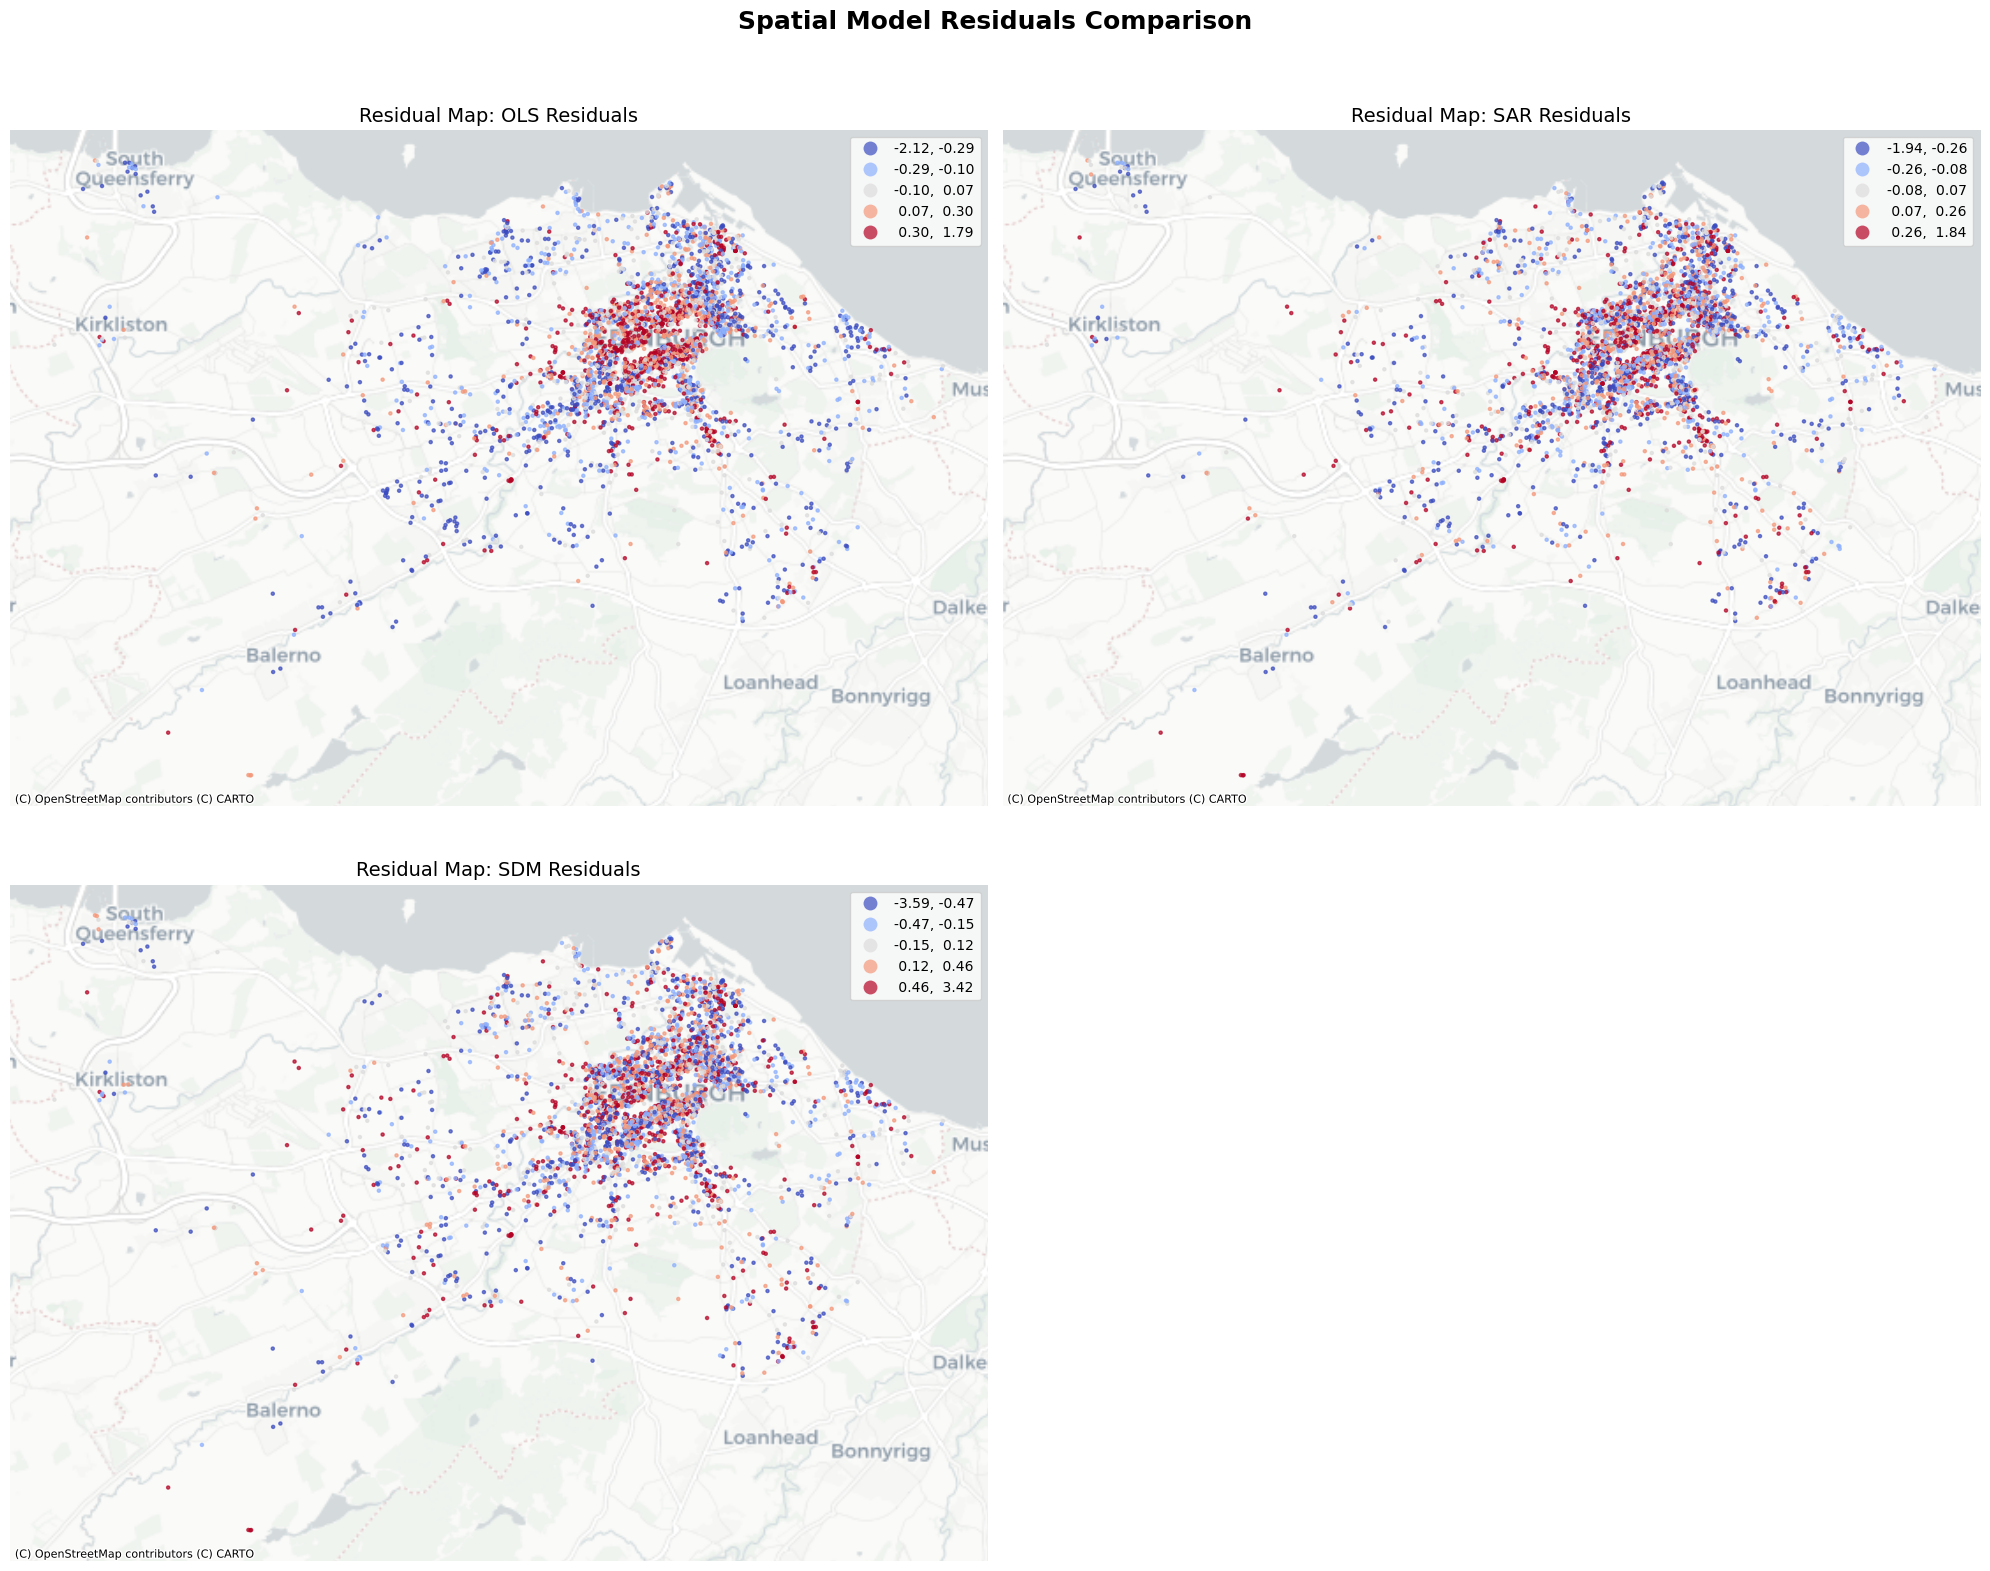

In [146]:
columns = ['ols_resid', 'sar_resid', 'sdm_resid']
titles = ['OLS Residuals', 'SAR Residuals', 'SDM Residuals']

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(columns, titles)):
    ax = axes[i]
    gdf.plot(
        column=col,
        cmap='coolwarm',
        scheme='quantiles',
        k=5,
        markersize=5,
        legend=True,
        ax=ax,
        alpha=0.7
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    ax.set_title(f'Residual Map: {title}', fontsize=14)
    ax.axis('off')

# Hide the 4th (unused) subplot
axes[3].set_visible(False)

plt.suptitle('Spatial Model Residuals Comparison', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [147]:
# Moran's I test for spatial autocorrelation in SAR residuals
residuals = sar.u.flatten()
moran = Moran(residuals, w_knn)

print("=== Global Moran's I Test on SAR Residuals ===")
print(f"Moran's I:     {moran.I:.4f}")
print(f"Expected I:    {moran.EI:.4f}")
print(f"Z-score:       {moran.z_sim:.4f}")
print(f"P-value:       {moran.p_sim:.4f}")
print()

# Moran's I test for spatial autocorrelation in SDM residuals
residuals = sdm.u.flatten()
moran = Moran(residuals, w_knn)

print("=== Global Moran's I Test on SDM Residuals ===")
print(f"Moran's I:     {moran.I:.4f}")
print(f"Expected I:    {moran.EI:.4f}")
print(f"Z-score:       {moran.z_sim:.4f}")
print(f"P-value:       {moran.p_sim:.4f}")
print()

=== Global Moran's I Test on SAR Residuals ===
Moran's I:     0.0244
Expected I:    -0.0002
Z-score:       4.1836
P-value:       0.0010

=== Global Moran's I Test on SDM Residuals ===
Moran's I:     -0.0097
Expected I:    -0.0002
Z-score:       -1.5867
P-value:       0.0600



The Global Moran's I test for the spatial error, spatial Lag, and Durbin models show an improvement compared to the OLS model. SDM produces a Moran's I value closer to 0. However, it's p-value is non-significant at the $\alpha = 0.05$ level, so the result can not be trusted to a high degree of confidence.

The SEM and SAR models capture the spatial dependence better than the Durbin model.

### 2.5 Geographically Weighted Regression

For GWR, standardise the dependent and independent features using the mean and standard deviation.

The bandwidth for GWR must also be selected, it is selected such that the AIC score is minimised.

Due to errors arising from mulitcollinearity, the dummy variables for room types are reduced to private room only. Where 1 implies the listing is a private room, and 0 suggest otherwise.

In [148]:
# MGWR functions
from mgwr.gwr import GWR,MGWR
from mgwr.sel_bw import Sel_BW

In [ ]:
x_cols = ['bedrooms', 'number_of_reviews', 'host_is_superhost_binary','private_room']
x = df_updated[x_cols].values
y = df_updated[y_col].values.reshape(-1, 1)

In [165]:
# standardise the data.
X = (x - x.mean(axis=0))/x.std(axis=0)
y = (y - y.mean(axis=0))/y.std(axis=0)

In [167]:
# Find optimal bandwidth for GWR:
gwr_selector = Sel_BW(coords, y, X)
gwr_bw = gwr_selector.search(verbose=True,criterion='AICc')

print("Selected optimal bandwidth is:", gwr_bw)

Bandwidth:  1628.0 , score:  8322.19
Bandwidth:  2603.0 , score:  8531.11
Bandwidth:  1025.0 , score:  8181.44
Bandwidth:  653.0 , score:  8083.06
Bandwidth:  422.0 , score:  7987.56
Bandwidth:  280.0 , score:  7905.97
Bandwidth:  192.0 , score:  7857.98
Bandwidth:  138.0 , score:  7857.73
Bandwidth:  104.0 , score:  7903.99
Bandwidth:  158.0 , score:  7848.55
Bandwidth:  171.0 , score:  7850.18
Bandwidth:  151.0 , score:  7849.88
Bandwidth:  163.0 , score:  7847.27
Bandwidth:  166.0 , score:  7848.50
Bandwidth:  161.0 , score:  7848.01
Bandwidth:  164.0 , score:  7847.34
Bandwidth:  162.0 , score:  7847.95
Selected optimal bandwidth is: 163.0


In [168]:
# Fit the GWR model with the bandwidth = 163.0
gwr_results = GWR(coords, y, X, bw = gwr_bw, name_x = x_cols).fit()
gwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                4181
Number of covariates:                                                     5

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                           2076.588
Log-likelihood:                                                   -4469.599
AIC:                                                               8949.198
AICc:                                                              8951.219
BIC:                                                             -32744.177
R2:                                                                   0.503
Adj. R2:                                                              0.503

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [178]:
# Morans I for GWR results:
w = Queen.from_dataframe(gdf)
w.transform = 'R'

gwr_residuals = gwr_results.resid_response.reshape(-1)
residual_moran = Moran(gwr_residuals, w)
residual_moran.I

print("=== Global Moran's I Test on GWR Residuals ===")
print(f"Moran's I:     {residual_moran.I:.4f}")
print(f"Expected I:    {residual_moran.EI:.4f}")
print(f"Z-score:       {residual_moran.z_sim:.4f}")
print(f"P-value:       {residual_moran.p_sim:.4f}")

C:\Users\sammi\AppData\Local\Temp\ipykernel_23664\1816060523.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


=== Global Moran's I Test on GWR Residuals ===
Moran's I:     0.0421
Expected I:    -0.0002
Z-score:       4.7267
P-value:       0.0010


For the GWR model, the fit produces the following results:
- R<sup>2</sup><sub>GWR</sub>= 0.681
- AICc<sub>GWR</sub> = 7847.272
- Morans I<sub>GWR</sub> = 0.04

So the, R<sup>2</sup> value for GWR has increased from the SDM R<sup>2</sup> (0.549), but the AIC and Morans I has increased. This could suggest the GWR model is overfitting, this can be investigated by fitting a multiscale GWR model.

### 2.6 Multiscale GWR:

In [172]:
# Find optimal bandwidth for GWR:
mgwr_selector = Sel_BW(coords, y, X, multi=True)
mgwr_bw = mgwr_selector.search(verbose=True)

print("Selected optimal bandwidth is:", mgwr_bw)

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Current iteration: 1 ,SOC: 0.0024612
Bandwidths: 69.0, 164.0, 1127.0, 307.0, 78.0
Current iteration: 2 ,SOC: 0.0006837
Bandwidths: 64.0, 166.0, 1786.0, 340.0, 78.0
Current iteration: 3 ,SOC: 0.000272
Bandwidths: 64.0, 166.0, 2120.0, 422.0, 78.0
Current iteration: 4 ,SOC: 9.22e-05
Bandwidths: 64.0, 166.0, 2121.0, 422.0, 78.0
Current iteration: 5 ,SOC: 3.89e-05
Bandwidths: 64.0, 166.0, 2121.0, 422.0, 78.0
Current iteration: 6 ,SOC: 2.29e-05
Bandwidths: 64.0, 166.0, 2121.0, 422.0, 78.0
Current iteration: 7 ,SOC: 1.58e-05
Bandwidths: 64.0, 166.0, 2121.0, 422.0, 78.0
Current iteration: 8 ,SOC: 1.19e-05
Bandwidths: 64.0, 166.0, 2121.0, 422.0, 78.0
Current iteration: 9 ,SOC: 9.5e-06
Bandwidths: 64.0, 166.0, 2121.0, 422.0, 78.0
Selected optimal bandwidth is: [  64.  166. 2121.  422.   78.]


In [174]:
mgwr_results = MGWR(coords, y, X, selector=mgwr_selector,name_x=x_cols).fit()

Inference:   0%|          | 0/1 [00:00<?, ?it/s]

In [180]:
mgwr_results.summary()

# Morans I for mGWR results:
w = Queen.from_dataframe(gdf)
w.transform = 'R'

mgwr_residuals = mgwr_results.resid_response.reshape(-1)
residual_moran_mgwr = Moran(gwr_residuals, w)
residual_moran_mgwr.I

print("=== Global Moran's I Test on mGWR Residuals ===")
print(f"Moran's I:     {residual_moran_mgwr.I:.4f}")
print(f"Expected I:    {residual_moran_mgwr.EI:.4f}")
print(f"Z-score:       {residual_moran_mgwr.z_sim:.4f}")
print(f"P-value:       {residual_moran_mgwr.p_sim:.4f}")

Model type                                                         Gaussian
Number of observations:                                                4181
Number of covariates:                                                     5

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                           2076.588
Log-likelihood:                                                   -4469.599
AIC:                                                               8949.198
AICc:                                                              8951.219
BIC:                                                             -32744.177
R2:                                                                   0.503
Adj. R2:                                                              0.503

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

C:\Users\sammi\AppData\Local\Temp\ipykernel_23664\3457540886.py:4: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


=== Global Moran's I Test on GWR Residuals ===
Moran's I:     0.0421
Expected I:    -0.0002
Z-score:       4.8032
P-value:       0.0010


Similar to the GWR model, the R<sup>2</sup> value for mGWR has increased. However, the AIC<sub>c</sub> has decreased slightly, yet still higher than the Spatial Durbin Model.
- R<sup>2</sup><sub>mGWR</sub>= 0.700
- AICc<sub>mGWR</sub> = 7748.667
- Morans I<sub>mGWR</sub> = 0.04

So, for much greater complexity in the model, mGWR only yields a very small improvement in results. It is unlikely that GWR and mGWR are the best models for the Airbnb listings in Edinburgh.

However, the coefficients for the GWR and mGWR model can be mapped, accounting for the adjusted t-values, to assess how significant the coefficients are in each location.

### 2.7 Visualise GWR and mGWR results:

In [194]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mgwr.utils import shift_colormap,truncate_colormap
from matplotlib import cm,colors
import contextily as ctx

import math

def param_plots(result, gdf, names=[], filter_t=False, figsize=(20, 16)):
    
    k = gwr_results.k
    n_cols = 2
    n_rows = math.ceil(k / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize)
    axs = axs.ravel()

    cmap = cm.get_cmap("bwr")
    norm = colors.BoundaryNorm(np.arange(-0.8, 0.9, 0.1), ncolors=256)
    vmin, vmax = -0.8, 0.8

    for j in range(k):
        gdf_plot = pd.concat([gdf, pd.DataFrame(np.hstack([result.params, result.bse]))], axis=1)
        gdf_plot.plot(ax=axs[j], column=j, vmin=vmin, vmax=vmax,
                      cmap=cmap, norm=norm, linewidth=0.1,
                      edgecolor='white', alpha=0.7,aspect=1
                      )

        ctx.add_basemap(axs[j], source=ctx.providers.CartoDB.Positron)
        axs[j].set_title(f'Parameter estimates of\n{names[j]}', fontsize=14)
        axs[j].axis('off')

        if filter_t:
            rslt_filtered_t = result.filter_tvals()
            if (rslt_filtered_t[:, j] == 0).any():
                gdf[rslt_filtered_t[:, j] == 0].plot(color='lightgrey', ax=axs[j], 
                                                     linewidth=0.1, edgecolor='white',
                                                     aspect=1
                                                     )

    # Hide unused axes
    for i in range(k, len(axs)):
        axs[i].set_visible(False)

    # Shared colorbar
    cax = fig.add_axes([0.99, 0.2, 0.025, 0.6])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    fig.colorbar(sm, cax=cax)

    plt.suptitle('GWR Parameter Estimates', fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()

    return fig

#### GWR Coefficients:

C:\Users\sammi\AppData\Local\Temp\ipykernel_23664\2213177872.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("bwr")
C:\Users\sammi\AppData\Local\Temp\ipykernel_23664\2213177872.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


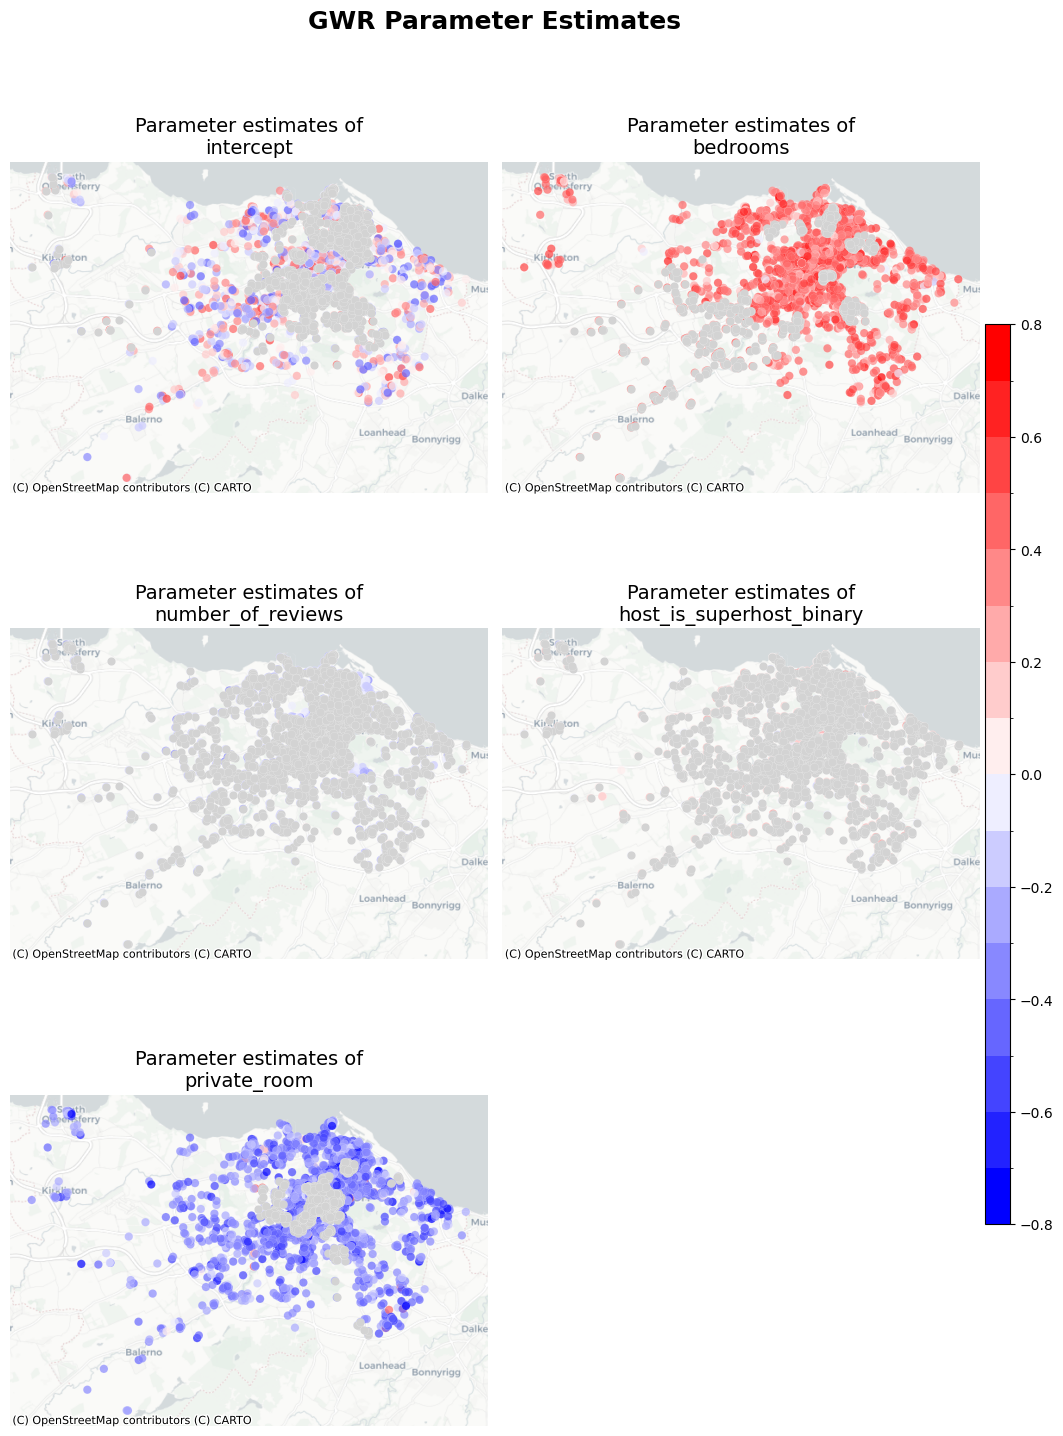

In [195]:
param_plots(gwr_results, gdf, names=['intercept'] + x_cols, figsize = (10,15), filter_t=True)

#### mGWR Coefficients:

C:\Users\sammi\AppData\Local\Temp\ipykernel_23664\2213177872.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("bwr")
C:\Users\sammi\AppData\Local\Temp\ipykernel_23664\2213177872.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


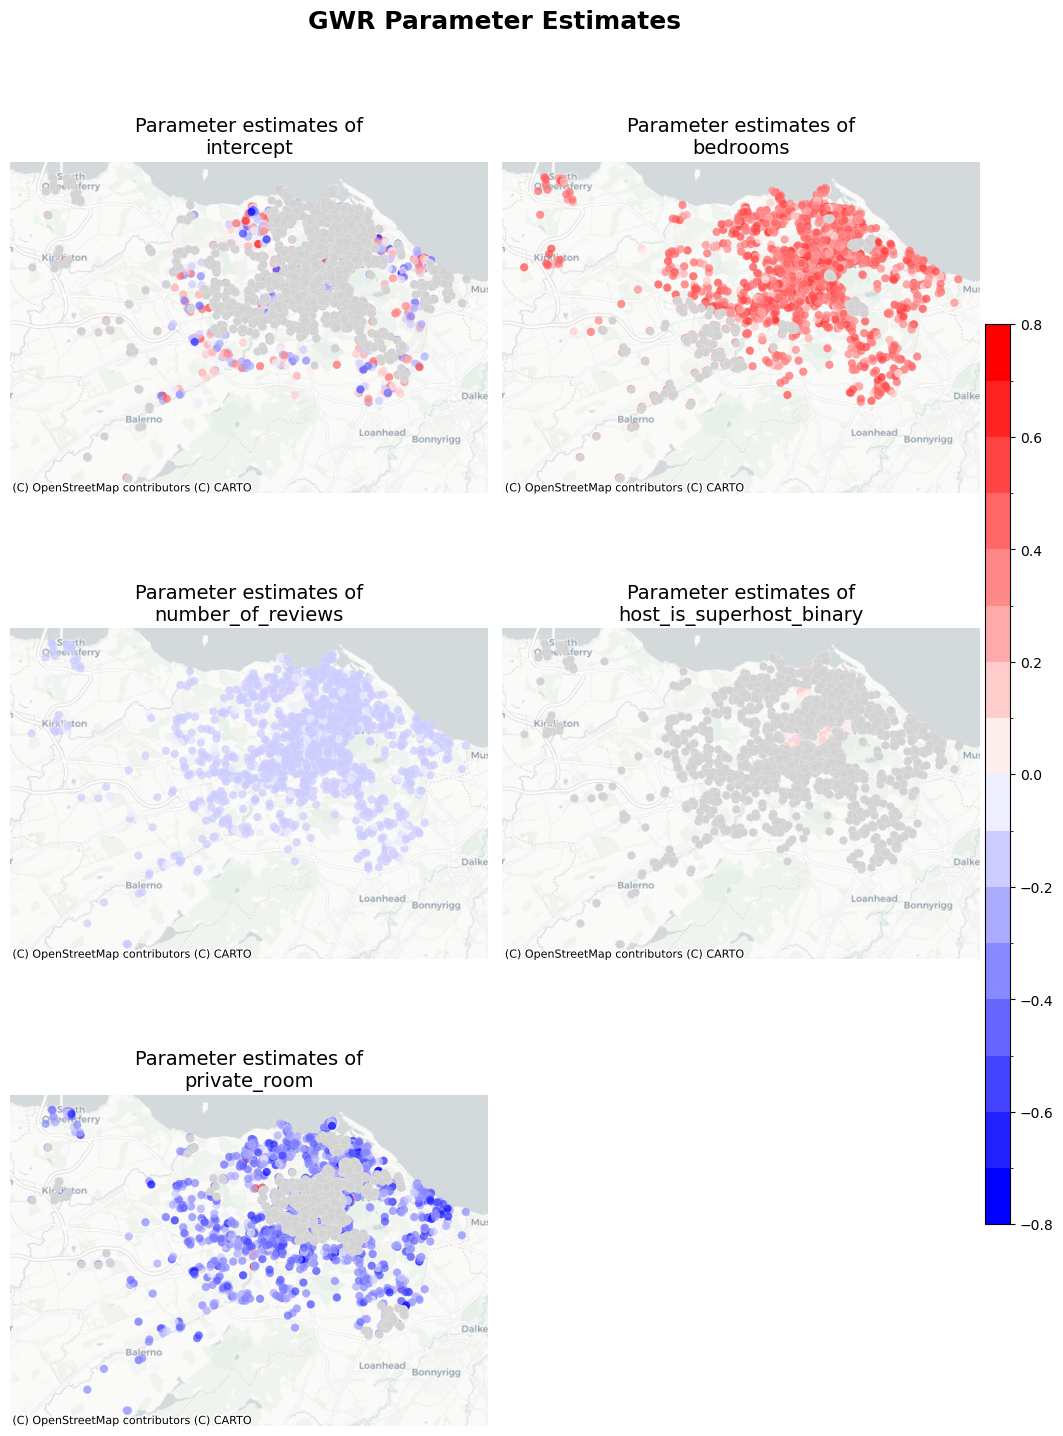

In [196]:
param_plots(mgwr_results, gdf, names=['intercept'] + x_cols,figsize = (10,15), filter_t=True)

From the plots for GWR and mGWR coefficients, it is clear the features *number_of_reviews* and *host_is_superhost_binary* are non-significant factors towards the model. However, number of reviews has some relevance in the mGWR model, nonethless it is a week relationship with (log) price of listings.

However, the number of bedrooms and the private room variable do show some significance towards the model. Interestingly, they show opposite behaviours. For example, bedrooms is positively associated with listing price, with reduced significance away from the centre of Edinburgh, whereas the private room variable shows a negative association with listing price, and less significance towards the centre of Edinburgh.

### 3 Model Evaluation

The OLS and spatial regression models are compared to the (m)GWR results:

| Metric                    | OLS | SEM | SAR | SDM | GWR | MGWR |
| ------------------------- | --- | --- | --- | --- | --- | ---- |
| Adjusted R²               |     |     |     |     | 0.681    |  0.700    |
| AICc                      |     |     |     |     | 7847.3    |   7748.7   |
| Moran's I of residuals    |     |     |     |     | 0.04    |   0.04   |
| Moran's I P-value         |     |     |     |     | 0.001    |   0.001   |
